In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
Flu_weather = pd.read_csv("NY_Flu_Weather_Final_Weekly.csv")

Flu_weather.head()

,County,Year,Month,Season,Region,Week,Week Ending Date,Disease,Infected,Avg household size,...,Longitude,Prob_infected,County_Density,Ending Date,level_2,avg_temp_prior_week,avg_humidity_prior_week,avg_dew_point_prior_week,avg_precip_prior_week,avg_wind_speed_prior_week
0,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_A,4,2.3,...,-73.977,0.000013,582.162575,2009-10-10,7.0,52.136235,75.422893,44.082307,NaN,NaN
1,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_B,0,2.3,...,-73.977,0.000000,582.162575,2009-10-10,7.0,52.136235,75.422893,44.082307,NaN,NaN
2,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_UNSPECIFIED,0,2.3,...,-73.977,0.000000,582.162575,2009-10-10,7.0,52.136235,75.422893,44.082307,NaN,NaN
3,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,41,10/17/2009,INFLUENZA_A,11,2.3,...,-73.977,0.000036,582.162575,2009-10-17,14.0,39.730165,68.109046,29.425700,NaN,NaN
4,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,41,10/17/2009,INFLUENZA_B,0,2.3,...,-73.977,0.000000,582.162575,2009-10-17,14.0,39.730165,68.109046,29.425700,NaN,NaN


In [10]:
# See which counties/years have the most '60 degree' weeks
outlier_check = Flu_weather[Flu_weather['avg_temp_prior_week'] == 60]
print(outlier_check['County'].value_counts())
print(outlier_check['Year'].value_counts())

# This catches 59.9, 60.1, etc.
outlier_check = Flu_weather[Flu_weather['avg_temp_prior_week'].between(59.5, 60.5)]
print(outlier_check['County'].value_counts().head())

# Check for 'dead' counties
weather_variance = Flu_weather.groupby('County')['avg_temp_prior_week'].nunique()
print(weather_variance[weather_variance == 1])

Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
County
NASSAU              36
HERKIMER            24
GENESEE             21
KINGS (BROOKLYN)    21
SUFFOLK             21
Name: count, dtype: int64
Series([], Name: avg_temp_prior_week, dtype: int64)


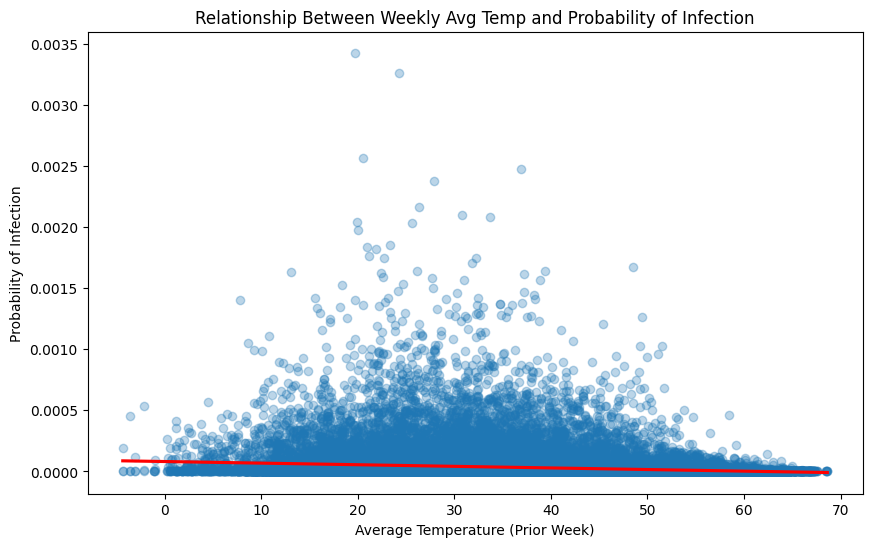

In [11]:
plt.figure(figsize=(10, 6))
sns.regplot(data=Flu_weather, x='avg_temp_prior_week', y='Prob_infected', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Relationship Between Weekly Avg Temp and Probability of Infection')
plt.xlabel('Average Temperature (Prior Week)')
plt.ylabel('Probability of Infection')
plt.show()


In [12]:
# Check which counties are contributing to the 50-degree pillar
# We look for values very close to 50 (e.g., 49.9 to 50.1)
pillar_50 = Flu_weather[Flu_weather['avg_temp_prior_week'].between(49.9, 50.1)]

print("--- Counties with most 50-degree readings ---")
print(pillar_50['County'].value_counts().head(10))

# Check if these are 'dead' counties (constant 50) or just occasional
dead_50_counties = Flu_weather.groupby('County')['avg_temp_prior_week'].nunique()
print("\nCounties with almost zero variance (Potential API ghosts):")
print(dead_50_counties[dead_50_counties < 5]) # Adjust threshold as needed

--- Counties with most 50-degree readings ---
County
NEW YORK (MANHATTAN)        12
RICHMOND (STATEN ISLAND)    12
SUFFOLK                     12
NASSAU                       9
ST. LAWRENCE                 9
TIOGA                        9
WASHINGTON                   9
WESTCHESTER                  9
BRONX                        6
BROOME                       6
Name: count, dtype: int64

Counties with almost zero variance (Potential API ghosts):
County
WYOMING    0
YATES      0
Name: avg_temp_prior_week, dtype: int64


In [13]:
%pip install geopy


   ---------------------------------------- 0/2 [geographiclib]
   ---------------------------------------- 0/2 [geographiclib]
   ---------------------------------------- 0/2 [geographiclib]
   ---------------------------------------- 0/2 [geographiclib]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   ------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import pandas as pd
from geopy.geocoders import Nominatim
import time

# 1. Setup your list of counties
counties = ["Genesee County, NY", "Hamilton County, NY", "Jefferson County, NY", "Kings County, NY"]
geolocator = Nominatim(user_agent="weather_app_validator")

coord_data = []

print("--- Starting Geocoding ---")
for county in counties:
    try:
        # Fetching location
        location = geolocator.geocode(county)
        if location:
            coord_data.append({
                "County": county,
                "Lat": round(location.latitude, 4),
                "Lon": round(location.longitude, 4)
            })
        else:
            coord_data.append({"County": county, "Lat": None, "Lon": None})
        
        # Nominatim requires a 1-second delay between requests
        time.sleep(1) 
    except Exception as e:
        print(f"Error geocoding {county}: {e}")

df_coords = pd.DataFrame(coord_data)

# 2. VALIDATION CHECK: Are the coordinates unique?
# If two counties map to the exact same Lat/Lon, you'll get identical weather data.
duplicates = df_coords[df_coords.duplicated(subset=['Lat', 'Lon'], keep=False)]

# 3. VALIDATION CHECK: Are any coordinates missing?
missing = df_coords[df_coords['Lat'].isna()]

print("\n--- Validation Results ---")
if not duplicates.empty:
    print("CRITICAL: Found duplicate coordinates for different counties:")
    print(duplicates)
else:
    print("Success: All coordinates are unique.")

if not missing.empty:
    print("\nWARNING: Could not find coordinates for:")
    print(missing)

# 4. Filter for only valid, unique coordinates before calling the API
df_clean_coords = df_coords.dropna().drop_duplicates(subset=['Lat', 'Lon'])

print("\nCleaned Dataframe for API calls:")
print(df_clean_coords)

--- Starting Geocoding ---

--- Validation Results ---
Success: All coordinates are unique.

Cleaned Dataframe for API calls:
                 County      Lat      Lon
0    Genesee County, NY  43.0103 -78.1780
1   Hamilton County, NY  43.6308 -74.4659
2  Jefferson County, NY  44.0593 -75.9996
3      Kings County, NY  40.6456 -73.9559
